In [1]:
# ================================
# 4. RNN 실습
# 목표:
# - 순차 데이터 분류
# - RNN(LSTM) 모델 학습
# - 학습 결과 저장
# - 저장된 모델결과 불러오기
# - 신규 시퀸스 예측
# - 학습결과 및 예측결과 시각화
# ================================

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# ================================
# 1. 데이터 생성
# ================================

# 샘플 수 정의
n_samples = 1500

# 시퀸스 길이
seq_len = 50

# 클래스 수 정의
n_classes = 3

# 빈 리스트 생성
X = []
y = []

# 클래스 별 시퀸스 생성
for i in range(n_samples):
    # 시간축 생성
    t = np.linspace(0, 2 * np.pi, seq_len)

    # 클래스를 랜덤하게 선택
    label = np.random.randint(0,3)

    # 클래스 0이면 sine 패턴을 생성
    if label == 0:
        seq = np.sin(t) + np.random.normal(0, 0.1, seq_len)

    # 클래스 1이면 cosine 패턴을 생성
    elif label == 0:
        seq = np.sin(t) + np.random.normal(0, 0.1, seq_len)

    # 클래스 1이면 cosine 패턴을 생성
    elif label == 1:
        seq = np.cos(t) + np.random.normal(0, 0.1, seq_len)

    # 클래스 2이면 증가 추세 패턴을 생성
    else:
        seq = np.linspace(-1, 1, seq_len) + np.random.normal(0,0.1,seq_len)

    # 시퀸스 데이터 추가
    X.append(seq)
    # 라벨도 추가
    y.append(label)

# numpy 배열로 변환
X = np.array(X)
y = np.array(y)

# RNN 입력 형태인 (샘플 수. 시퀸스 길이, 특성 수) 로 reshape 필요
X = X.reshape(-1, seq_len, 1)

In [15]:
y

array([0, 2, 0, ..., 2, 2, 0], shape=(1500,))

In [16]:
# ================================
# 2. 데이터 분리
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# ================================
# 3. 모델 정의
# ================================

model = Sequential()

# 첫 번째 LSTM 층을 추가
model.add(LSTM(64, input_shape=(seq_len, 1), return_sequences=False))

# 드롭아웃 추가
model.add(Dropout(0.2))

# 완전연결층 추가
model.add(Dense(32, activation='relu'))

# 출력층 추가
model.add(Dense(n_classes, activation='softmax'))

C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
# ================================
# 4. 모델 컴파일 정의
# ================================
model.compile(
    optimizer = 'adam',
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience=5,
    restore_best_weights= True
)

In [27]:
# ================================
# 5. 모델 학습
# ================================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
    

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7583 - loss: 0.6593 - val_accuracy: 1.0000 - val_loss: 0.1484
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0381 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 7.8846e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 5.4836e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 7.4670e-04 - val_accuracy: 1.0000 - val_loss: 4.0827e-04
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 5.4507e-04 - val_accuracy: 1.0000 - val_loss: 3.1263e-04
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 4.6180e-0

In [28]:
# ================================
# 6. 성능 평가
# ================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# 결과 출력
print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

테스트 손실:  1.8075133993988857e-05
테스트 정확도:  1.0


In [29]:
# ================================
# 7. 신규 데이터 예측
# ================================

# 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [31]:
# ================================
# 8. 학습 결과 저장
# ================================

# 저장
model.save('./results/RNN_LSTM_Model.h5')

# 읽어오기
loaded_model = tf.keras.models.load_model('./results/RNN_LSTM_Model.h5')

In [34]:
# ================================
# 9. 신규 데이터 예측
# ================================

# 신규 5개 패턴을 사용
new_seq = X_test[:5]

# 신규 시퀀스를 예측
new_prob = loaded_model.predict(new_seq)

# 최종 클래스를 계산
new_pred = np.argmax(new_prob, axis=1)

#예측결과 출력
for i in range(len(new_seq)):
    print(f"{i+1}번 시퀀스 - 예측클래스: {new_pred[i]}, 확률분포 : {new_prob[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1번 시퀀스 - 예측클래스: 2, 확률분포 : [3.1964662e-06 2.0868962e-05 9.9997592e-01]
2번 시퀀스 - 예측클래스: 2, 확률분포 : [3.1631339e-06 2.1683345e-05 9.9997509e-01]
3번 시퀀스 - 예측클래스: 0, 확률분포 : [9.9998665e-01 8.0245145e-06 5.4190018e-06]
4번 시퀀스 - 예측클래스: 0, 확률분포 : [9.999869e-01 7.786661e-06 5.310740e-06]
5번 시퀀스 - 예측클래스: 2, 확률분포 : [3.4261150e-06 2.1290049e-05 9.9997520e-01]


## 현재 시퀀스 사진을 보면, 사인인지 코사인인지 탄젠트인지 잘 모르기에 시각화를 하는것이 중요함.

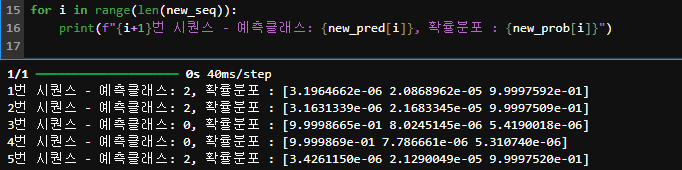


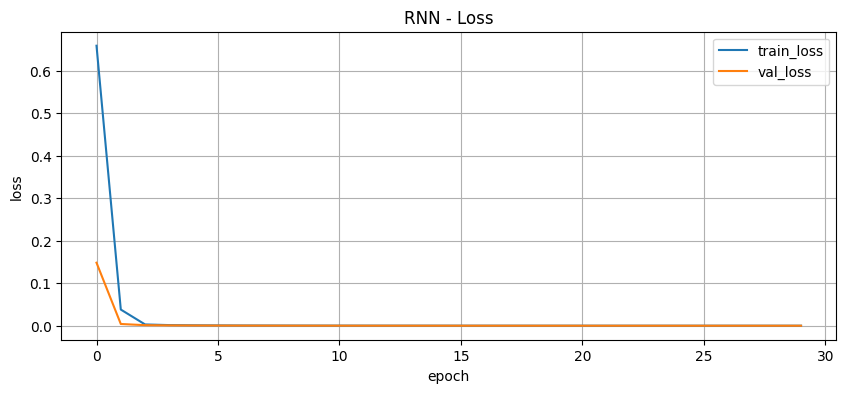

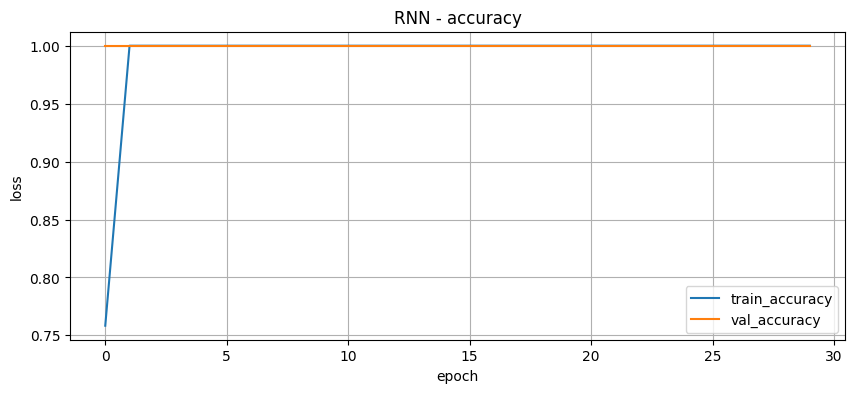

In [35]:
# 학습 손실 그패프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('RNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()                      

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('RNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

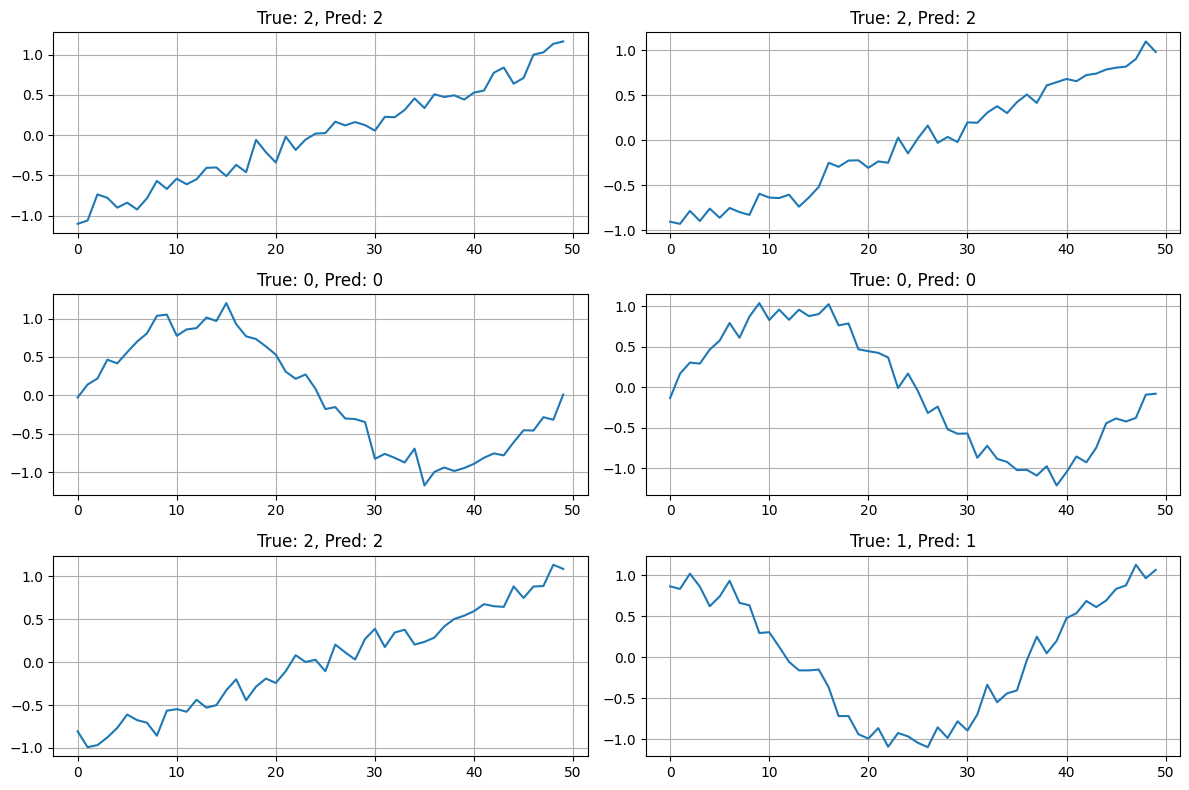

In [36]:
# 시퀀스패턴과 예측 결과 시각화
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.plot(X_test[i].flatten())
    plt.title(f"True: {y_test[i]}, Pred: {y_pred[i]}")
    plt.grid(True)
plt.tight_layout()
plt.show()

# AI는 패턴을 분석하는 역할이다.